In [ ]:
#Importamos la libreria y cargamos los datos
import pandas as pd
df = pd.read_csv("/content/Datos.csv", encoding="latin-1")

In [ ]:
# Vemos la informacion del data frame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Edad                        45000 non-null  int64  
 1   Sexo                        45000 non-null  object 
 2   Mayor nivel educativo       45000 non-null  object 
 3   Ingreso anual               45000 non-null  int64  
 4   Años de xperiencia laboral  45000 non-null  int64  
 5   Estado de vivienda          45000 non-null  object 
 6   Monto solicitado            45000 non-null  int64  
 7   Destino de los fondos       45000 non-null  object 
 8   Tasa de interés             45000 non-null  float64
 9   Porcentaje del ingreso      45000 non-null  float64
 10  Plazo en años               45000 non-null  int64  
 11  Puntaje                     45000 non-null  int64  
 12  Préstamos previos impagos   45000 non-null  object 
 13  Estado                      450

In [ ]:
# Imprimimos las columnas
print(df.columns)

Index(['Edad', 'Sexo', 'Mayor nivel educativo', 'Ingreso anual',
       'Años de xperiencia laboral', 'Estado de vivienda', 'Monto solicitado',
       'Destino de los fondos', 'Tasa de interés', 'Porcentaje del ingreso',
       'Plazo en años', 'Puntaje', 'Préstamos previos impagos', 'Estado'],
      dtype='object')


In [ ]:
# Observamos los primeros datos
(df.head())

,Edad,Sexo,Mayor nivel educativo,Ingreso anual,Años de xperiencia laboral,Estado de vivienda,Monto solicitado,Destino de los fondos,Tasa de interés,Porcentaje del ingreso,Plazo en años,Puntaje,Préstamos previos impagos,Estado
0,22,FEMENINO,MAESTRíA,71948,0,INQUILINO,35000,PERSONAL,16.02,0.49,3,561,NO,OTORGADO
1,21,FEMENINO,SECUNDARIO,12282,0,PROPIETARIO,1000,EDUCACION,11.14,0.08,2,504,SI,RECHAZADO
2,25,FEMENINO,SECUNDARIO,12438,3,HIPOTECA,5500,SALUD,12.87,0.44,3,635,NO,OTORGADO
3,23,FEMENINO,UNIVERSITARIO,79753,0,INQUILINO,35000,SALUD,15.23,0.44,2,675,NO,OTORGADO
4,24,MASCULINO,MAESTRíA,66135,1,INQUILINO,35000,SALUD,14.27,0.53,4,586,NO,OTORGADO


In [ ]:
# Vemos la distribucion por edad
df["Edad"].value_counts().sort_index()

,count
Edad,
20,17
21,1289
22,4236
23,5254
24,5138
25,4507
26,3659
27,3095
28,2728


In [ ]:
# Filtramos por edad = 50

df_50=df[df['Edad'] == 50]

In [ ]:
# Genero la tupla donde estan los de 50 años para saber cuantos son
# y que concidan con lo contado anteriormente
df_50.shape

(56, 14)

In [ ]:
# Dividimos 75% train / 25% test
n = len(df_50)
train = df_50.iloc[:int(0.75*n)]
test = df_50.iloc[int(0.75*n):]

# Seleccionamos SOLO positivos para FIND-S
train_pos = train[train["Estado"] == "OTORGADO"]

# Atributos de H
atributos = ["Sexo","Mayor nivel educativo","Estado de vivienda","Préstamos previos impagos"]


In [ ]:
for atributo in atributos:
    print("\n", atributo)
    print(df[atributo].unique())
    # solo para ver que valor puede tomar los atributos (pero no hace falta)


 Sexo
['FEMENINO' 'MASCULINO']

 Mayor nivel educativo
['MAESTRíA' 'SECUNDARIO' 'UNIVERSITARIO' 'TERCIARIO' 'DOCTORADO']

 Estado de vivienda
['INQUILINO' 'PROPIETARIO' 'HIPOTECA' 'OTRO']

 Préstamos previos impagos
['NO' 'SI']


In [ ]:
# Implementamos funcion para algoritmo FIND-S
def find_s(datos, atributos):
    h = None

    for i in range(len(datos)):
        fila = datos.iloc[i]
        x = []

        for attr in atributos:
            x.append(fila[attr])

        if h is None:
            h = x.copy()
        else:
            for j in range(len(h)):
                if h[j] != x[j]:
                    h[j] = "?"
    return h

In [ ]:
# Obtenemos la hipótesis conseguida por la funcion FIND-S
h = find_s(train_pos, atributos)

print("Hipótesis final:", h)


Hipótesis final: ['?', '?', '?', 'NO']


In [ ]:
# Función de predicción
def predecir(h, fila, atributos):
    for i in range(len(h)):
        if h[i] != "?" and h[i] != fila[atributos[i]]:
            return "RECHAZADO"
    return "OTORGADO"

In [ ]:
# Aplicamos la prediccion al conjunto de prueba
predicciones = []

for i in range(len(test)):
    fila = test.iloc[i]
    pred = predecir(h, fila, atributos)
    predicciones.append(pred)



# Mostramos los resultados
test_resultados = test.copy()
test_resultados["Prediccion"] = predicciones

(test_resultados[atributos + ["Estado", "Prediccion"]])

,Sexo,Mayor nivel educativo,Estado de vivienda,Préstamos previos impagos,Estado,Prediccion
31634,MASCULINO,TERCIARIO,HIPOTECA,SI,RECHAZADO,RECHAZADO
31667,MASCULINO,SECUNDARIO,HIPOTECA,SI,RECHAZADO,RECHAZADO
31715,FEMENINO,SECUNDARIO,INQUILINO,SI,RECHAZADO,RECHAZADO
31754,MASCULINO,MAESTRíA,HIPOTECA,NO,RECHAZADO,OTORGADO
31773,MASCULINO,SECUNDARIO,INQUILINO,NO,OTORGADO,OTORGADO
31966,MASCULINO,TERCIARIO,HIPOTECA,NO,OTORGADO,OTORGADO
31976,MASCULINO,MAESTRíA,INQUILINO,NO,OTORGADO,OTORGADO
31977,FEMENINO,SECUNDARIO,HIPOTECA,NO,RECHAZADO,OTORGADO
32054,FEMENINO,TERCIARIO,INQUILINO,NO,OTORGADO,OTORGADO
32130,MASCULINO,TERCIARIO,HIPOTECA,NO,RECHAZADO,OTORGADO


# 2 Matriz de confusión

In [ ]:
# Calculamos los datos de la matriz
TP = ((test_resultados["Estado"] == "OTORGADO") & (test_resultados["Prediccion"] == "OTORGADO")).sum()

TN = ((test_resultados["Estado"] == "RECHAZADO") & (test_resultados["Prediccion"] == "RECHAZADO")).sum()

FP = ((test_resultados["Estado"] == "RECHAZADO") & (test_resultados["Prediccion"] == "OTORGADO")).sum()

FN = ((test_resultados["Estado"] == "OTORGADO") & (test_resultados["Prediccion"] == "RECHAZADO")).sum()

In [ ]:
# Visualizamos los datos de la matriz estilo "matriz"

print("\nMatriz de confusión:")
print("                           Predicho OTORGADO   Predicho RECHAZADO")
print(f"Verdadero OTORGADO          {TP}                  {FN}")
print(f"Verdadero RECHAZADO         {FP}                  {TN}")


Matriz de confusión:
                           Predicho OTORGADO   Predicho RECHAZADO
Verdadero OTORGADO          4                  0
Verdadero RECHAZADO         4                  6


In [ ]:
# Funciones para calcular metricas
def accuracy (TP, TN, FP, FN):
  return (TP + TN) / (TP + TN + FP + FN)

def recall (TP, FN):
  return TP / (TP + FN)

def especificidad (TN, FP):
  return TN / (TN + FP)

def precision(TP, FP):
  return TP / (TP + FP)

def f1_score(precision, recall):
  return 2 * (precision * recall) / (precision + recall)

def tasa_verdadero_positivo(TP, FN):
  return TP / (TP + FN)

def tasa_falso_positivo(TN, FP):
  return 1 - (TN / (TN + FP))

In [ ]:
# Calculamos las métricas y mostramos
acc = accuracy(TP, TN, FP, FN)
rec = recall(TP, FN)
esp = especificidad(TN, FP)
prec = precision(TP, FP)
f1 = f1_score(prec, rec)
tpr = tasa_verdadero_positivo(TP, FN)
fpr = tasa_falso_positivo(TN, FP)

# Mostrar resultados
print("=== MÉTRICAS ===")
print(f"Accuracy: {acc:.4f}")
print(f"Recall : {rec:.4f}")
print(f"Especificidad: {esp:.4f}")
print(f"Precisión: {prec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Tasa de Verdaderos Positivos (TPR): {tpr:.4f}")
print(f"Tasa de Falsos Positivos (FPR): {fpr:.4f}")

=== MÉTRICAS ===
Accuracy: 0.7143
Recall : 1.0000
Especificidad: 0.6000
Precisión: 0.5000
F1-score: 0.6667
Tasa de Verdaderos Positivos (TPR): 1.0000
Tasa de Falsos Positivos (FPR): 0.4000


# 3  clasificador naïve de Bayes conjunto 40 - 45

In [ ]:
# Filtro por edad
df_40_45 = df[(df["Edad"] >= 40) & (df["Edad"] <= 45)]

In [ ]:
df_40_45

,Edad,Sexo,Mayor nivel educativo,Ingreso anual,Años de xperiencia laboral,Estado de vivienda,Monto solicitado,Destino de los fondos,Tasa de interés,Porcentaje del ingreso,Plazo en años,Puntaje,Préstamos previos impagos,Estado
29120,40,FEMENINO,UNIVERSITARIO,1440915,19,HIPOTECA,10000,SALUD,11.01,0.01,16,637,SI,RECHAZADO
29124,45,MASCULINO,MAESTRíA,96924,25,INQUILINO,35000,SALUD,11.01,0.36,13,566,NO,OTORGADO
29127,44,MASCULINO,SECUNDARIO,703125,24,HIPOTECA,20000,SALUD,11.01,0.03,16,563,NO,OTORGADO
29129,40,MASCULINO,UNIVERSITARIO,649823,16,HIPOTECA,35000,SALUD,15.99,0.05,11,614,NO,OTORGADO
29131,43,FEMENINO,MAESTRíA,600812,22,HIPOTECA,25000,EMPRESA,12.61,0.04,14,685,NO,RECHAZADO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44887,44,MASCULINO,TERCIARIO,74199,21,INQUILINO,10289,DEUDAS,14.66,0.14,13,599,NO,OTORGADO
44916,42,FEMENINO,SECUNDARIO,100310,21,OTRO,12000,EDUCACION,16.16,0.12,14,665,NO,OTORGADO
44947,42,MASCULINO,DOCTORADO,705960,21,HIPOTECA,20686,PERSONAL,10.74,0.03,16,689,NO,OTORGADO
44972,43,MASCULINO,TERCIARIO,184295,20,HIPOTECA,25000,EDUCACION,20.00,0.14,15,720,NO,OTORGADO


In [ ]:
# definimos los atributos categoricos y clase objetivo
atributos_categoricos = ["Sexo", "Mayor nivel educativo", "Estado de vivienda", "Destino de los fondos", "Préstamos previos impagos"]
clase_objetivo = "Estado"

In [ ]:
# Mezclamos aleatoriamente el data frame
df_40_45_mezclado = df_40_45.sample(frac=1, random_state=11)


# aca separamos el data frame mezclado en 80% train 20% test
n = len(df_40_45_mezclado)

train_mezclado = df_40_45_mezclado.iloc[:int(0.8*n)]
test_mezclado = df_40_45_mezclado.iloc[int(0.8*n):]

In [ ]:
train_mezclado

,Edad,Sexo,Mayor nivel educativo,Ingreso anual,Años de xperiencia laboral,Estado de vivienda,Monto solicitado,Destino de los fondos,Tasa de interés,Porcentaje del ingreso,Plazo en años,Puntaje,Préstamos previos impagos,Estado
34786,42,MASCULINO,SECUNDARIO,135412,18,HIPOTECA,25000,PERSONAL,12.76,0.18,16,648,NO,RECHAZADO
37294,42,FEMENINO,TERCIARIO,67772,20,HIPOTECA,2000,DEUDAS,11.53,0.03,15,664,SI,RECHAZADO
30322,44,FEMENINO,UNIVERSITARIO,70337,26,INQUILINO,7000,PERSONAL,7.40,0.10,11,664,SI,RECHAZADO
29808,43,FEMENINO,TERCIARIO,47827,21,HIPOTECA,8000,EMPRESA,9.99,0.17,16,699,SI,RECHAZADO
30952,41,MASCULINO,UNIVERSITARIO,85714,15,HIPOTECA,12000,PERSONAL,6.62,0.14,11,657,NO,RECHAZADO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30212,40,FEMENINO,SECUNDARIO,39663,15,INQUILINO,6000,VIVIENDA,7.90,0.15,15,570,NO,OTORGADO
30683,40,MASCULINO,TERCIARIO,75099,16,INQUILINO,8000,DEUDAS,8.49,0.11,15,588,SI,RECHAZADO
30826,45,MASCULINO,UNIVERSITARIO,80390,24,HIPOTECA,9000,EDUCACION,14.59,0.11,15,731,SI,RECHAZADO
31156,40,MASCULINO,TERCIARIO,76231,18,HIPOTECA,7500,SALUD,19.04,0.10,12,588,NO,OTORGADO


In [ ]:
test_mezclado

,Edad,Sexo,Mayor nivel educativo,Ingreso anual,Años de xperiencia laboral,Estado de vivienda,Monto solicitado,Destino de los fondos,Tasa de interés,Porcentaje del ingreso,Plazo en años,Puntaje,Préstamos previos impagos,Estado
29457,40,FEMENINO,UNIVERSITARIO,60935,19,INQUILINO,1500,DEUDAS,9.32,0.02,16,642,SI,RECHAZADO
33171,41,MASCULINO,SECUNDARIO,144972,17,HIPOTECA,20000,EDUCACION,10.26,0.14,11,579,SI,RECHAZADO
30359,45,MASCULINO,TERCIARIO,63731,25,HIPOTECA,14000,EDUCACION,11.01,0.22,16,648,SI,RECHAZADO
30870,42,MASCULINO,MAESTRíA,82866,21,HIPOTECA,5000,EMPRESA,7.51,0.06,17,720,NO,RECHAZADO
41603,43,MASCULINO,TERCIARIO,72909,20,INQUILINO,15000,VIVIENDA,11.35,0.21,12,680,NO,RECHAZADO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30104,41,MASCULINO,UNIVERSITARIO,56058,17,HIPOTECA,7700,EMPRESA,11.71,0.14,17,612,SI,RECHAZADO
39522,41,MASCULINO,SECUNDARIO,152508,18,HIPOTECA,5870,EMPRESA,9.83,0.04,12,704,NO,RECHAZADO
42019,43,MASCULINO,MAESTRíA,321623,22,HIPOTECA,21779,DEUDAS,12.09,0.07,13,637,SI,RECHAZADO
32652,42,MASCULINO,TERCIARIO,87300,18,HIPOTECA,14892,SALUD,6.22,0.17,10,673,NO,RECHAZADO


In [ ]:
# Diccionario para guardar los valores posibles de cada atributo
valores_atributos = {}

# Recorremos cada atributo categórico
for attr in atributos_categoricos:

    # Guardamos los valores únicos de esa columna
    valores_atributos[attr] = train_mezclado[attr].unique()

for attr in valores_atributos:
    print(attr, ":", valores_atributos[attr])

Sexo : ['MASCULINO' 'FEMENINO']
Mayor nivel educativo : ['SECUNDARIO' 'TERCIARIO' 'UNIVERSITARIO' 'MAESTRíA' 'DOCTORADO']
Estado de vivienda : ['HIPOTECA' 'INQUILINO' 'PROPIETARIO' 'OTRO']
Destino de los fondos : ['PERSONAL' 'DEUDAS' 'EMPRESA' 'SALUD' 'VIVIENDA' 'EDUCACION']
Préstamos previos impagos : ['NO' 'SI']


In [ ]:
# Obtener clases posibles
clases = train_mezclado[clase_objetivo].unique()

# para guardar probabilidades
prob_clase = {}

# Calcular probabilidad de cada clase
for clase in clases:

    cantidad_clase = (train_mezclado[clase_objetivo] == clase).sum()

    prob_clase[clase] = cantidad_clase / len(train_mezclado)

for clase in prob_clase:
    print(clase, ":",  round(prob_clase[clase], 4))

RECHAZADO : 0.7956
OTORGADO : 0.2044


In [ ]:
# Probabilidades condicionales
# P(Xj = valor | Yk)

prob_condicional = {}

# Recorremos cada clase (OTORGADO / RECHAZADO)
for clase in clases:

    # Filtramos filas pertenecientes a esa clase
    datos_clase = train_mezclado[train_mezclado[clase_objetivo] == clase]

    # Creamos diccionario interno para la clase
    prob_condicional[clase] = {}

    # Recorremos cada atributo categórico
    for attr in atributos_categoricos:

        # Creamos diccionario interno para el atributo
        prob_condicional[clase][attr] = {}

        # Valores posibles del atributo
        valores = valores_atributos[attr]

        # Cantidad total de filas de esa clase
        total_clase = len(datos_clase)

        for valor in valores:

            #cuántas veces aparece ese valor en esa clase
            cantidad = (datos_clase[attr] == valor).sum()

            # Aplicamos Laplace smoothing
            probabilidad = (cantidad + 1) / (total_clase + len(valores))

            # Guardamos probabilidad
            prob_condicional[clase][attr][valor] = round(float(probabilidad),4)

# Mostrar ejemplo para verificar

print(prob_condicional["OTORGADO"]["Préstamos previos impagos"])
print(prob_condicional["RECHAZADO"]["Préstamos previos impagos"])
print(prob_condicional["RECHAZADO"]["Mayor nivel educativo"])
print(prob_condicional["OTORGADO"]["Mayor nivel educativo"])

{'NO': 0.9957, 'SI': 0.0043}
{'NO': 0.407, 'SI': 0.593}
{'SECUNDARIO': 0.3553, 'TERCIARIO': 0.3377, 'UNIVERSITARIO': 0.159, 'MAESTRíA': 0.0921, 'DOCTORADO': 0.0559}
{'SECUNDARIO': 0.3487, 'TERCIARIO': 0.3487, 'UNIVERSITARIO': 0.1303, 'MAESTRíA': 0.1134, 'DOCTORADO': 0.0588}


In [ ]:
# ============================
# Función de predicción Naive Bayes
# ============================

def predecir_bayes(fila):

    probabilidades = {}

    for clase in clases:

        # Empezamos con P(Y)
        prob = prob_clase[clase]

        # Multiplicamos por P(Xj | Y)
        for attr in atributos_categoricos:

            valor = fila[attr]

            prob *= prob_condicional[clase][attr][valor]

        # Guardamos probabilidad final
        probabilidades[clase] = prob

    # Elegimos la clase con mayor probabilidad
    mejor_clase = max(probabilidades, key=probabilidades.get) # .get: recibe una key y devuelve su valor numérico.

    return mejor_clase


# ============================
# Aplicamos al conjunto de test
# ============================

predicciones = []

for i in range(len(test_mezclado)):

    fila = test_mezclado.iloc[i]

    pred = predecir_bayes(fila)

    predicciones.append(pred)


# ============================
# Guardamos los resultados
# ============================

test_resultados = test_mezclado.copy()

test_resultados["Prediccion"] = predicciones


#mostramos
test_resultados

,Edad,Sexo,Mayor nivel educativo,Ingreso anual,Años de xperiencia laboral,Estado de vivienda,Monto solicitado,Destino de los fondos,Tasa de interés,Porcentaje del ingreso,Plazo en años,Puntaje,Préstamos previos impagos,Estado,Prediccion
29457,40,FEMENINO,UNIVERSITARIO,60935,19,INQUILINO,1500,DEUDAS,9.32,0.02,16,642,SI,RECHAZADO,RECHAZADO
33171,41,MASCULINO,SECUNDARIO,144972,17,HIPOTECA,20000,EDUCACION,10.26,0.14,11,579,SI,RECHAZADO,RECHAZADO
30359,45,MASCULINO,TERCIARIO,63731,25,HIPOTECA,14000,EDUCACION,11.01,0.22,16,648,SI,RECHAZADO,RECHAZADO
30870,42,MASCULINO,MAESTRíA,82866,21,HIPOTECA,5000,EMPRESA,7.51,0.06,17,720,NO,RECHAZADO,RECHAZADO
41603,43,MASCULINO,TERCIARIO,72909,20,INQUILINO,15000,VIVIENDA,11.35,0.21,12,680,NO,RECHAZADO,RECHAZADO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30104,41,MASCULINO,UNIVERSITARIO,56058,17,HIPOTECA,7700,EMPRESA,11.71,0.14,17,612,SI,RECHAZADO,RECHAZADO
39522,41,MASCULINO,SECUNDARIO,152508,18,HIPOTECA,5870,EMPRESA,9.83,0.04,12,704,NO,RECHAZADO,RECHAZADO
42019,43,MASCULINO,MAESTRíA,321623,22,HIPOTECA,21779,DEUDAS,12.09,0.07,13,637,SI,RECHAZADO,RECHAZADO
32652,42,MASCULINO,TERCIARIO,87300,18,HIPOTECA,14892,SALUD,6.22,0.17,10,673,NO,RECHAZADO,RECHAZADO


In [ ]:
# ============================
# Matriz de confusión
# ============================

TP = ((test_resultados[clase_objetivo] == "OTORGADO") &
      (test_resultados["Prediccion"] == "OTORGADO")).sum()

TN = ((test_resultados[clase_objetivo] == "RECHAZADO") &
      (test_resultados["Prediccion"] == "RECHAZADO")).sum()

FP = ((test_resultados[clase_objetivo] == "RECHAZADO") &
      (test_resultados["Prediccion"] == "OTORGADO")).sum()

FN = ((test_resultados[clase_objetivo] == "OTORGADO") &
      (test_resultados["Prediccion"] == "RECHAZADO")).sum()



print("Matriz de confusión:")
print("                           Predicho OTORGADO   Predicho RECHAZADO")
print(f"Verdadero OTORGADO                  {TP}                  {FN}")
print(f"Verdadero RECHAZADO                 {FP}                  {TN}")

Matriz de confusión:
                           Predicho OTORGADO   Predicho RECHAZADO
Verdadero OTORGADO                  25                  37
Verdadero RECHAZADO                 25                  199


In [ ]:
acc = accuracy(TP, TN, FP, FN)
rec = recall(TP, FN)
esp = especificidad(TN, FP)
prec = precision(TP, FP)
f1 = f1_score(prec, rec)

In [ ]:
print("\nMétricas:")

print("Accuracy:", round(acc, 4))
print("Recall:", round(rec, 4))
print("Precision:", round(prec, 4))
print("Especificidad:", round(esp, 4))
print("F1 Score:", round(f1, 4))


Métricas:
Accuracy: 0.7832
Recall: 0.4032
Precision: 0.5
Especificidad: 0.8884
F1 Score: 0.4464


In [ ]:
# ============================
# Probabilidad Naive Bayes
# ============================

def probabilidad_bayes(fila):

    probabilidades = {}

    for clase in clases:

        prob = prob_clase[clase]

        for attr in atributos_categoricos:

            valor = fila[attr]

            prob *= prob_condicional[clase][attr][valor]

        probabilidades[clase] = prob

    # Normalizamos probabilidades
    suma = sum(probabilidades.values())

    for clase in probabilidades:
        probabilidades[clase] = probabilidades[clase] / suma

    return probabilidades

In [ ]:
# ============================
# Scores para ROC
# ============================

scores_otorgado = []

for i in range(len(test_mezclado)):

    fila = test_mezclado.iloc[i]

    probs = probabilidad_bayes(fila)

    scores_otorgado.append(probs["OTORGADO"])

In [ ]:
# ============================
# Etiquetas reales binarias
# ============================

y_real = []

for valor in test_resultados[clase_objetivo]:

    if valor == "OTORGADO":
        y_real.append(1)
    else:
        y_real.append(0)
# ============================
# Curva ROC manual
# ============================
import numpy as np

umbrales = np.linspace(0, 1, 100)

tpr_lista = []
fpr_lista = []

for umbral in umbrales:

    TP = TN = FP = FN = 0

    for i in range(len(scores_otorgado)):

        pred = 1 if scores_otorgado[i] >= umbral else 0

        real = y_real[i]

        if pred == 1 and real == 1:
            TP += 1
        elif pred == 0 and real == 0:
            TN += 1
        elif pred == 1 and real == 0:
            FP += 1
        elif pred == 0 and real == 1:
            FN += 1

    # TPR
    if (TP + FN) > 0:
        tpr = TP / (TP + FN)
    else:
        tpr = 0

    # FPR
    if (FP + TN) > 0:
        fpr = FP / (FP + TN)
    else:
        fpr = 0

    tpr_lista.append(tpr)
    fpr_lista.append(fpr)

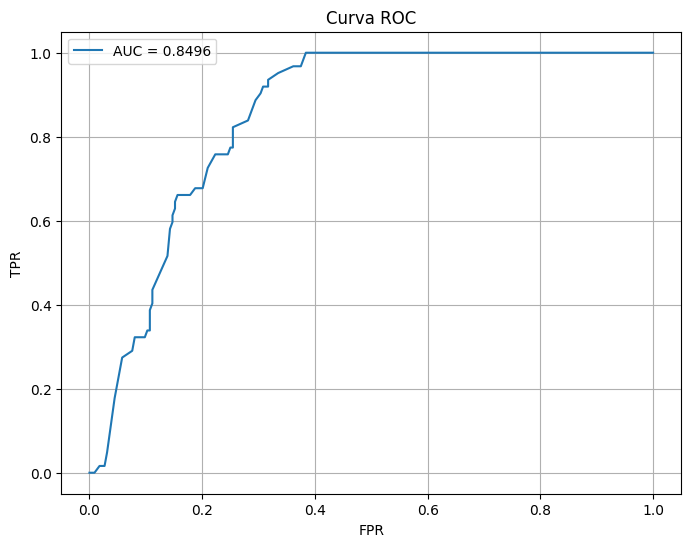

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular AUC
pares = sorted(zip(fpr_lista, tpr_lista)) #generamos tuplas para poder ordenar sin romper los puntos de la curva

fpr_ordenado = [p[0] for p in pares] #ordenamos FPR en orden creciente
tpr_ordenado = [p[1] for p in pares] #ordenamos TPR en orden creciente

auc = np.trapezoid(tpr_ordenado, fpr_ordenado) #Integra para calcular AUC

plt.figure(figsize=(8,6))

# Curva ROC con AUC en la leyenda
plt.plot(fpr_lista, tpr_lista, label=f"AUC = {auc:.4f}")


plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")

plt.legend()
plt.grid(True)

plt.show()